# Technical Analysis
Calculating and visualizing key technical indicators including Moving Averages,
RSI, Bollinger Bands and MACD for Apple stock.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
tickers = ["AAPL", "TSLA","MSFT", "GOOGL", "AMZN"]

stocks={}

for ticker in tickers:
    stocks[ticker]= pd.read_csv(f"../data/{ticker}.csv", index_col=0, parse_dates=True, skiprows=[1,2])
print("All stocks loaded!")

All stocks loaded!


In [4]:
df = stocks["AAPL"].copy()

df["SMA_20"] = df["Close"].rolling(window=20).mean()
df["SMA_50"] = df["Close"].rolling(window=50).mean()
df["SMA_200"] = df["Close"].rolling(window=200).mean()

df[["Close", "SMA_20", "SMA_50", "SMA_200"]].tail()

,Close,SMA_20,SMA_50,SMA_200
Price,,,,
2024-12-23,253.883118,243.695760,234.001649,209.838115
2024-12-24,256.797180,244.955379,234.541782,210.266141
2024-12-26,257.612701,246.146869,235.047558,210.695866
2024-12-27,254.201385,247.174258,235.526238,211.118940
2024-12-30,250.829803,247.913718,235.930135,211.515890


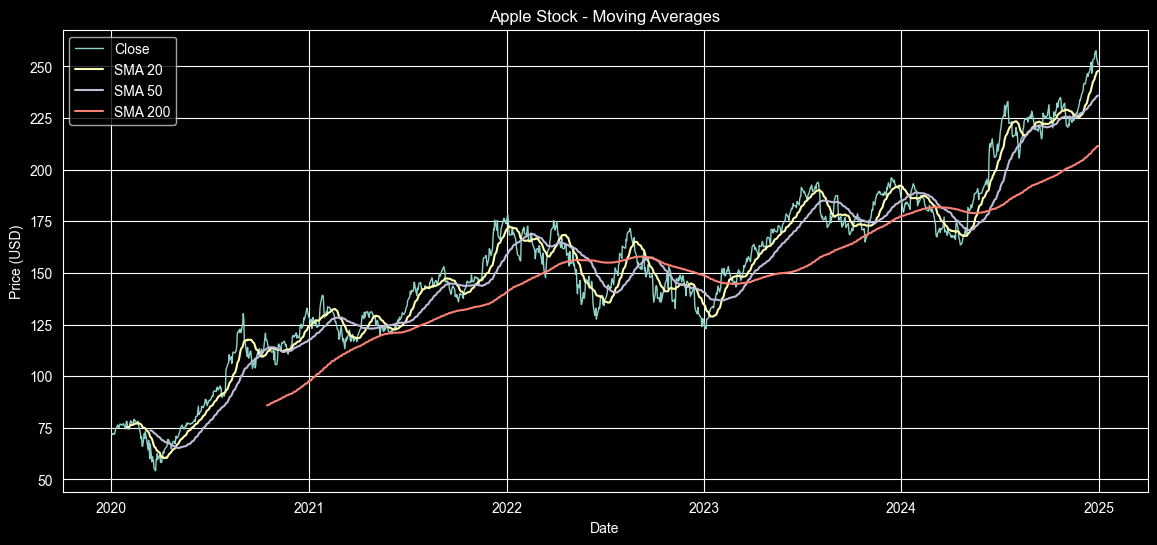

In [5]:
plt.figure(figsize=(14, 6))

plt.plot(df.index, df["Close"], label="Close", linewidth=1)
plt.plot(df.index, df["SMA_20"], label="SMA 20")
plt.plot(df.index, df["SMA_50"], label="SMA 50")
plt.plot(df.index, df["SMA_200"], label="SMA 200")

plt.title("Apple Stock - Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df["RSI"] = calculate_rsi(df["Close"])
print("RSI calculated!")

RSI calculated!


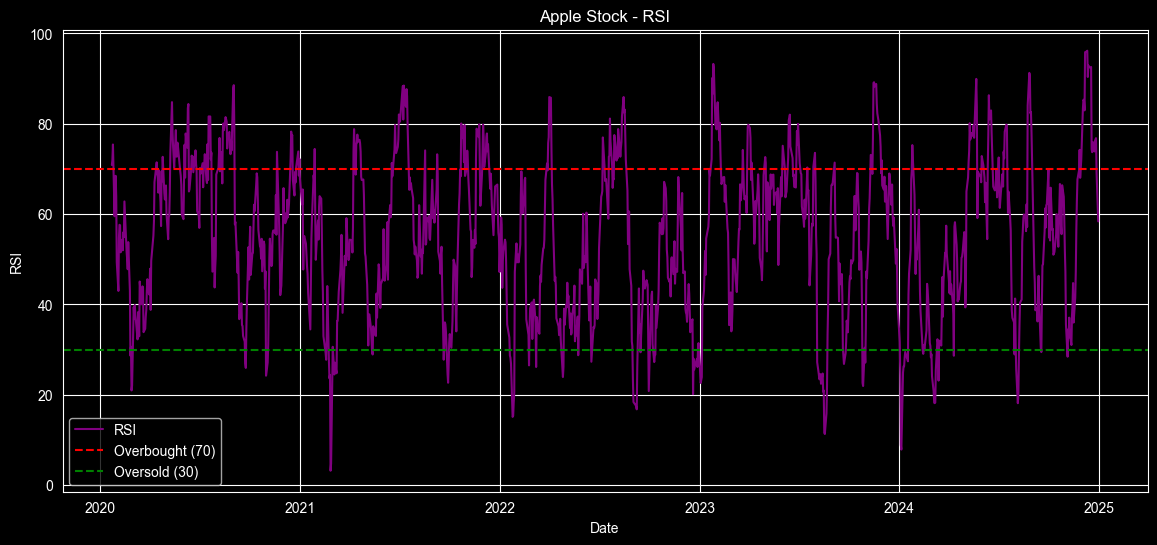

In [7]:
plt.figure(figsize=(14, 6))

plt.plot(df.index, df["RSI"], label="RSI", color="purple")
plt.axhline(y=70, color="red", linestyle="--", label="Overbought (70)")
plt.axhline(y=30, color="green", linestyle="--", label="Oversold (30)")

plt.title("Apple Stock - RSI")
plt.xlabel("Date")
plt.ylabel("RSI")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
df["BB_middle"] = df["Close"].rolling(window=20).mean()
df["BB_upper"] = df["BB_middle"] + 2 * df["Close"].rolling(window=20).std()
df["BB_lower"] = df["BB_middle"] - 2 * df["Close"].rolling(window=20).std()

print("Bollinger Bands calculated!")

Bollinger Bands calculated!


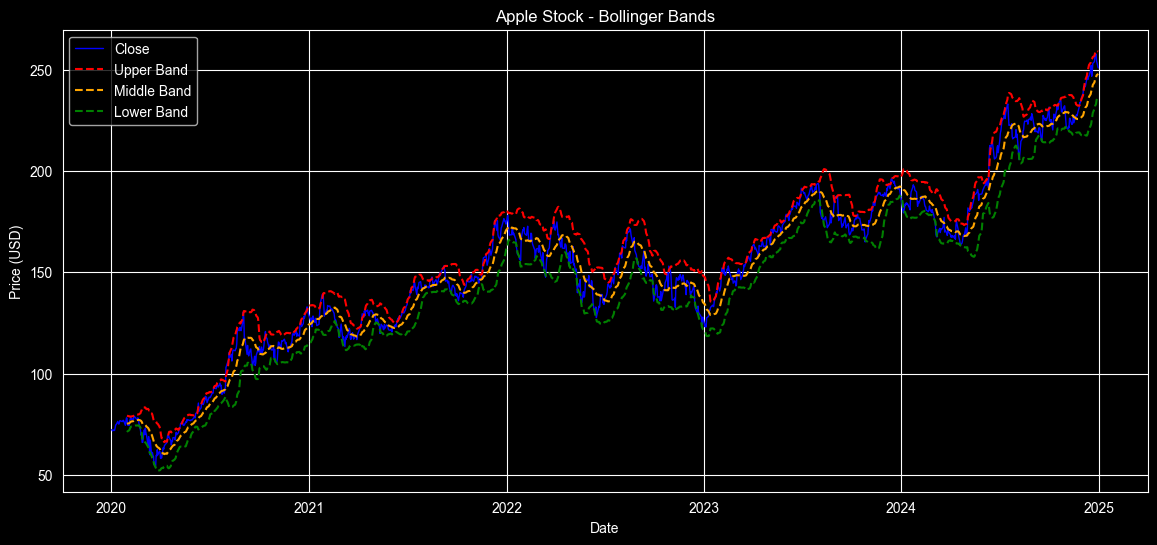

In [9]:
plt.figure(figsize=(14, 6))

plt.plot(df.index, df["Close"], label="Close", color="blue", linewidth=1)
plt.plot(df.index, df["BB_upper"], label="Upper Band", color="red", linestyle="--")
plt.plot(df.index, df["BB_middle"], label="Middle Band", color="orange", linestyle="--")
plt.plot(df.index, df["BB_lower"], label="Lower Band", color="green", linestyle="--")

plt.title("Apple Stock - Bollinger Bands")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
df["EMA_12"] = df["Close"].ewm(span=12).mean()
df["EMA_26"] = df["Close"].ewm(span=26).mean()
df["MACD"] = df["EMA_12"] - df["EMA_26"]
df["Signal"] = df["MACD"].ewm(span=9).mean()

print("MACD calculated!")

MACD calculated!


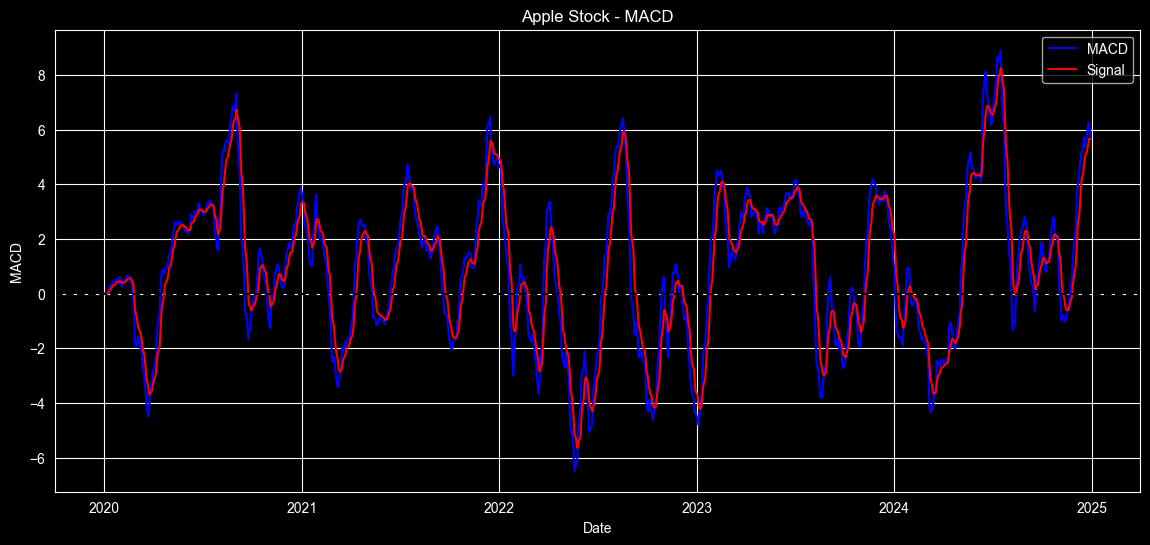

In [11]:
plt.figure(figsize=(14, 6))

plt.plot(df.index, df["MACD"], label="MACD", color="blue")
plt.plot(df.index, df["Signal"], label="Signal", color="red")
plt.axhline(y=0, color="black", linestyle="--")

plt.title("Apple Stock - MACD")
plt.xlabel("Date")
plt.ylabel("MACD")
plt.legend()
plt.grid(True)
plt.show()